# RQ2: Profit Erosion Concentration & Customer Segmentation Analysis

**Research Question 2 (RQ2):**
> *To what extent is profit erosion concentrated among a small subset of customers, and can customers be meaningfully segmented based on behavioral and erosion characteristics?*

## Executive Summary

This notebook conducts a comprehensive analysis of profit erosion concentration patterns across the customer base. The analysis is structured in three phases:

1. **Feature-Level Concentration Analysis** – Rank all features by concentration with statistical significance testing
2. **Customer-Level Concentration Analysis** – Deep dive into profit erosion distribution patterns  
3. **Customer Segmentation** – Identify behavioral segments within the return population

### Key Methodological Decisions

**Analysis Population:**
- Focus exclusively on **customers who made returns** (profit erosion > 0)
- Rationale: Including non-returners would create trivial "returner vs non-returner" segments
- Goal: Identify behavioral patterns **within** the return population

**Statistical Approach:**
- Gini coefficient for concentration measurement
- Bootstrap resampling for significance testing (1,000 iterations)
- Multiple feature comparison for comprehensive understanding

---

## Setup & Configuration

This section imports necessary libraries, configures the analysis environment, and creates output directories for processed data and visualizations.

In [26]:
# Standard library imports
import json
import warnings
from pathlib import Path
import sys

# Data manipulation
import numpy as np
import pandas as pd
from IPython.display import Image, display

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path.cwd()
while not (project_root / 'src').exists() and project_root.parent != project_root:
    project_root = project_root.parent
if not (project_root / 'src').exists():
    raise RuntimeError('Cannot find project root containing src directory.')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Project modules - Data Processing
from src.config import FIGURES_DIR, PROCESSED_DATA_DIR
from src.data_processing import load_processed_data
from src.feature_engineering import (
    aggregate_profit_erosion_by_customer,
    calculate_margins,
    calculate_profit_erosion,
    engineer_customer_behavioral_features,
    engineer_return_features,
)

# Project modules - RQ2 Analysis
from src.rq2_concentration import (
    bootstrap_gini_p_value,
    compute_pareto_table,
    concentration_comparison,
    gini_coefficient,
    lorenz_curve_points,
    top_n_customer_impact,
    top_x_customer_share_of_value,
    get_business_summary,
    rank_features_by_concentration,
    filter_significant_features,
    summarize_concentration_findings,
)

from src.visualization import (
    set_plot_style,
    plot_feature_concentration_ranking,
    plot_gini_vs_pareto_scatter,
    plot_pareto_curve,
    plot_lorenz_curve,
    plot_clustering_diagnostics,
    plot_cluster_erosion_comparison,
    plot_clustering_feature_importance,
)


from src.rq2_segmentation import (
    build_customer_segmentation_table,
    kmeans_fit_predict,
    select_numeric_features,
    silhouette_over_k,
    standardize_features,
    summarize_clusters,
    elbow_inertia_over_k,
    screen_clustering_features,
    analyze_feature_importance_for_clustering
)

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set plotting style
set_plot_style()
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Create output directories
data_dir = PROCESSED_DATA_DIR / "RQ2_SSL"
fig_dir = FIGURES_DIR / "RQ2_SSL"
data_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

print("✓ Setup complete")
print(f"  Data output: {data_dir}")
print(f"  Figures output: {fig_dir}")

✓ Setup complete
  Data output: c:\GitHub\unfc-capstone-project\data\processed\RQ2_SSL
  Figures output: c:\GitHub\unfc-capstone-project\figures\RQ2_SSL


## Data Loading & Preparation

Loading the processed transaction data and engineering customer-level features for concentration and segmentation analysis. This includes calculating profit erosion metrics, behavioral patterns, and return characteristics.

In [27]:
# Load SSL returns data
print("Loading SSL returns data...")

# Try different possible paths
possible_paths = [
    'data/raw/SSL_Returns_df_yoy.csv',
    '../data/raw/SSL_Returns_df_yoy.csv',
    './data/raw/SSL_Returns_df_yoy.csv'
]

ssl_raw = None
for path in possible_paths:
    if Path(path).exists():
        ssl_raw = pd.read_csv(path)
        print(f"  ✓ Loaded from: {path}")
        break

if ssl_raw is None:
    raise FileNotFoundError("SSL_Returns_df_yoy.csv not found. Please update the path.")

print(f"\n{'='*80}")
print("DATA LOADED")
print(f"{'='*80}")
print(f"Total return records: {len(ssl_raw):,}")

if 'Bill To Act #' in ssl_raw.columns:
    print(f"Unique accounts: {ssl_raw['Bill To Act #'].nunique():,}")
elif 'account_id' in ssl_raw.columns:
    print(f"Unique accounts: {ssl_raw['account_id'].nunique():,}")

Loading SSL returns data...
  ✓ Loaded from: ../data/raw/SSL_Returns_df_yoy.csv

DATA LOADED
Total return records: 133,800
Unique accounts: 13,616


In [28]:
# Engineer account-level features (SSL account-level aggregation)
print("Engineering features...")

# Identify account column
if 'Bill To Act #' in ssl_raw.columns:
    account_col = 'Bill To Act #'
elif 'account_id' in ssl_raw.columns:
    account_col = 'account_id'
else:
    raise ValueError("Could not identify account column")

# Parse date columns
date_cols = [c for c in ssl_raw.columns if 'date' in c.lower()]
for col in date_cols:
    ssl_raw[col] = pd.to_datetime(ssl_raw[col], errors='coerce')

# Find main date column (for recency/tenure)
if 'Booked Date' in ssl_raw.columns:
    main_date_col = 'Booked Date'
elif 'Date' in ssl_raw.columns:
    main_date_col = 'Date'
else:
    main_date_col = date_cols[0] if date_cols else None

max_date = ssl_raw[main_date_col].max() if main_date_col else None

# ---------------------------------------------------------------------
# IMPORTANT FIX: Distinguish actual RETURNS vs replacement ORDER lines
# ---------------------------------------------------------------------
if "Sales_Type" in ssl_raw.columns:
    is_return = (ssl_raw["Sales_Type"] == "RETURN")
else:
    # If Sales_Type not available, treat all rows as return-related
    is_return = pd.Series(True, index=ssl_raw.index)

ssl_raw["_is_return"] = is_return.astype(int)

# ---------------------------------------------------------------------
# IMPROVED per-line item price logic (align with rq3_validation mapping):
# - Prefer Reference Sale Amount / abs(qty) when available
# - Fallback to abs(CreditReturn Sales) / abs(qty) for RETURN lines
# ---------------------------------------------------------------------
if "Ordered Qty" in ssl_raw.columns:
    qty_ok = ssl_raw["Ordered Qty"].abs() > 0
else:
    qty_ok = pd.Series(False, index=ssl_raw.index)

if "Reference Sale Amount" in ssl_raw.columns:
    ref_ok = ssl_raw["Reference Sale Amount"].notna() & (ssl_raw["Reference Sale Amount"] > 0)
else:
    ref_ok = pd.Series(False, index=ssl_raw.index)

if "CreditReturn Sales" in ssl_raw.columns:
    cr_ok = ssl_raw["CreditReturn Sales"].notna()
else:
    cr_ok = pd.Series(False, index=ssl_raw.index)

if "Ordered Qty" in ssl_raw.columns:
    ssl_raw["_item_price"] = np.where(
        qty_ok & ref_ok,
        ssl_raw["Reference Sale Amount"] / ssl_raw["Ordered Qty"].abs(),
        np.where(
            is_return & qty_ok & cr_ok,
            ssl_raw["CreditReturn Sales"].abs() / ssl_raw["Ordered Qty"].abs(),
            np.nan,
        ),
    )
else:
    ssl_raw["_item_price"] = np.nan

# ---------------------------------------------------------------------
# Account-level aggregation
# - order_frequency: unique order count (ALL lines)
# - return_frequency: count of RETURN lines ONLY
# - total_items: count of ALL lines
# - total_profit_erosion: sum(total_loss) on RETURN lines ONLY (target)
# ---------------------------------------------------------------------
print("Building customer behavioral features...")

agg_dict = {}

if "Order Number" in ssl_raw.columns:
    agg_dict["order_frequency"] = ("Order Number", "nunique")

# total items (all lines) and return frequency (RETURN only)
if "Order Line ID" in ssl_raw.columns:
    agg_dict["total_items"] = ("Order Line ID", "count")
    agg_dict["return_frequency"] = ("_is_return", "sum")

# sales and margin proxies (all lines)
if "Reference Sale Amount" in ssl_raw.columns:
    agg_dict["total_sales"] = ("Reference Sale Amount", "sum")

if "gross_financial_loss" in ssl_raw.columns:
    agg_dict["total_margin"] = ("gross_financial_loss", "sum")
    agg_dict["avg_item_margin"] = ("gross_financial_loss", "mean")

# avg basket size (all lines) if present
if "Lines Per Order" in ssl_raw.columns:
    agg_dict["avg_basket_size"] = ("Lines Per Order", "mean")

# avg order value: aggregate at order-level then average per account
if "Order Number" in ssl_raw.columns and "Reference Sale Amount" in ssl_raw.columns:
    order_agg = (
        ssl_raw.groupby([account_col, "Order Number"])
        .agg(order_ref_sale=("Reference Sale Amount", "sum"))
        .reset_index()
    )
    avg_order_value = (
        order_agg.groupby(account_col)["order_ref_sale"]
        .mean()
        .rename("avg_order_value")
    )
else:
    avg_order_value = None

# avg item price (all lines) as mapping proxy
agg_dict["avg_item_price"] = ("_item_price", "mean")

# tenure and recency
if main_date_col and max_date is not None:
    agg_dict["_min_date"] = (main_date_col, "min")
    agg_dict["_max_date"] = (main_date_col, "max")

# total_loss exists: keep it for later, but DO NOT sum across ORDER lines for erosion
# We'll compute return-only erosion separately.
has_total_loss = "total_loss" in ssl_raw.columns

ssl_accounts = ssl_raw.groupby(account_col).agg(**agg_dict).reset_index()
ssl_accounts = ssl_accounts.rename(columns={account_col: "account_id"})

# Join avg_order_value if computed
if avg_order_value is not None:
    ssl_accounts = ssl_accounts.merge(
        avg_order_value.reset_index().rename(columns={account_col: "account_id"}),
        on="account_id",
        how="left",
    )

# Derived return rate
if "return_frequency" in ssl_accounts.columns and "total_items" in ssl_accounts.columns:
    ssl_accounts["customer_return_rate"] = ssl_accounts["return_frequency"] / ssl_accounts["total_items"]

# Tenure + recency
if "_min_date" in ssl_accounts.columns and "_max_date" in ssl_accounts.columns:
    ssl_accounts["_min_date"] = pd.to_datetime(ssl_accounts["_min_date"])
    ssl_accounts["_max_date"] = pd.to_datetime(ssl_accounts["_max_date"])
    ssl_accounts["customer_tenure_days"] = (ssl_accounts["_max_date"] - ssl_accounts["_min_date"]).dt.days
    ssl_accounts["purchase_recency_days"] = (max_date - ssl_accounts["_max_date"]).dt.days
    ssl_accounts = ssl_accounts.drop(columns=["_min_date", "_max_date"])

# ---------------------------------------------------------------------
# Return-only profit erosion target (fix for incorrect "returns in summary")
# ---------------------------------------------------------------------
if has_total_loss:
    erosion_by_account = (
        ssl_raw.loc[is_return]
        .groupby(account_col)["total_loss"]
        .sum()
        .rename("total_profit_erosion")
        .reset_index()
        .rename(columns={account_col: "account_id"})
    )
else:
    # Fallback: if total_loss not available, set erosion to 0 (cannot compute)
    erosion_by_account = pd.DataFrame({"account_id": ssl_accounts["account_id"], "total_profit_erosion": 0.0})

ssl_accounts = ssl_accounts.merge(erosion_by_account, on="account_id", how="left")
ssl_accounts["total_profit_erosion"] = pd.to_numeric(ssl_accounts["total_profit_erosion"], errors="coerce").fillna(0.0)

# Impute missing numeric values (median)
print("Handling missing values...")
numeric_cols = ssl_accounts.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if ssl_accounts[col].isna().any():
        ssl_accounts[col] = ssl_accounts[col].fillna(ssl_accounts[col].median())

# Create behavior and erosion tables for merge
print("Preparing tables for merge...")

behavioral_features = [
    "order_frequency",
    "return_frequency",
    "customer_return_rate",
    "avg_basket_size",
    "avg_order_value",
    "total_items",
    "total_sales",
    "total_margin",
    "avg_item_price",
    "avg_item_margin",
    "customer_tenure_days",
    "purchase_recency_days",
]

customer_behavior = ssl_accounts[["account_id"] + [f for f in behavioral_features if f in ssl_accounts.columns]].copy()
customer_behavior = customer_behavior.rename(columns={"account_id": "user_id"})

customer_erosion = ssl_accounts[["account_id", "total_profit_erosion"]].copy()
customer_erosion = customer_erosion.rename(columns={"account_id": "user_id"})

print("Building customer segmentation table...")
customer_segmentation = build_customer_segmentation_table(
    customer_behavior=customer_behavior,
    customer_erosion=customer_erosion,
    id_col="user_id",
)

# Analysis population = customers with non-zero return-only erosion
analysis_population = customer_segmentation[customer_segmentation["total_profit_erosion"] > 0].copy()

print(f"\n{'='*80}")
print("FEATURE ENGINEERING COMPLETE")
print(f"{'='*80}")
print(f"Total accounts: {len(customer_segmentation):,}")
print(f"Accounts with returns (erosion>0): {len(analysis_population):,} ({len(analysis_population)/len(customer_segmentation)*100:.1f}%)")
print(f"Total profit erosion (return-only): ${analysis_population['total_profit_erosion'].sum():,.2f}")

# Save datasets
customer_segmentation.to_parquet(data_dir / "customer_segmentation_table.parquet")
analysis_population.to_parquet(data_dir / "analysis_population.parquet")
print(f"\n✓ Data saved to {data_dir}")


Engineering features...
Building customer behavioral features...
Handling missing values...
Preparing tables for merge...
Building customer segmentation table...

FEATURE ENGINEERING COMPLETE
Total accounts: 13,616
Accounts with returns (erosion>0): 5,100 (37.5%)
Total profit erosion (return-only): $3,271,648.37

✓ Data saved to c:\GitHub\unfc-capstone-project\data\processed\RQ2_SSL


---

# Phase 1: Feature-Level Concentration Analysis

## Objective
Systematically rank all customer features by their concentration of profit erosion to identify which behavioral patterns or characteristics are most strongly associated with concentrated losses.

## Approach
For each feature in the customer dataset:
1. Calculate Gini coefficient measuring concentration of profit erosion
2. Compute Pareto metrics (top 20% share)
3. Perform bootstrap significance testing (H₀: Gini = 0)
4. Rank features by concentration strength

**Hypothesis:**
- H₀: Feature values show no concentration (Gini ≈ 0)
- H₁: Feature values exhibit significant concentration (Gini > 0, p < 0.05)

In [29]:
print(f"{'='*80}")
print("PHASE 1: FEATURE-LEVEL CONCENTRATION RANKING")
print(f"{'='*80}\n")

# Rank all features by concentration
print("Analyzing concentration across all features...")
print("(This may take a few minutes due to bootstrap resampling)\n")

feature_concentration = rank_features_by_concentration(
    df=analysis_population,
    id_col='user_id',
    n_bootstrap=1000,
    random_state=42,
    min_customers=10
)

print("✓ Concentration analysis complete\n")

# Display full ranking
print(f"{'='*80}")
print("COMPLETE FEATURE CONCENTRATION RANKING")
print(f"{'='*80}\n")
print(feature_concentration.to_string(index=False))

# Save results
feature_concentration.to_csv(data_dir / "feature_concentration_ranking.csv", index=False)
feature_concentration.to_parquet(data_dir / "feature_concentration_ranking.parquet")
print(f"\n✓ Results saved to {data_dir}/feature_concentration_ranking.*")

PHASE 1: FEATURE-LEVEL CONCENTRATION RANKING

Analyzing concentration across all features...
(This may take a few minutes due to bootstrap resampling)

✓ Concentration analysis complete

COMPLETE FEATURE CONCENTRATION RANKING

              feature  gini_coefficient  concentration_pct  p_value concentration_level  n_customers  top_20_pct_share
          total_sales            0.8107              81.07      0.0             Extreme         4970             84.56
         total_margin            0.7985              79.85      0.0             Extreme         4960             83.33
          total_items            0.7568              75.68      0.0             Extreme         5100             79.27
 total_profit_erosion            0.7489              74.89      0.0             Extreme         5100             78.84
     return_frequency            0.7352              73.52      0.0             Extreme         5100             78.65
      order_frequency            0.7286              72.86 

### Statistical Significance Filtering

Filter to retain only features with statistically significant concentration (p < 0.05), ensuring we focus on patterns that are unlikely to occur by chance.

In [30]:
# Filter to significant features only (p < 0.05)
significant_features = filter_significant_features(
    feature_concentration,
    alpha=0.05
)

print(f"{'='*80}")
print(f"STATISTICALLY SIGNIFICANT FEATURES (p < 0.05)")
print(f"{'='*80}\n")
print(f"Found {len(significant_features)} / {len(feature_concentration)} features with significant concentration\n")
print(significant_features.to_string(index=False))

# Save
significant_features.to_csv(data_dir / "significant_concentrated_features.csv", index=False)
print(f"\n✓ Saved to {data_dir}/significant_concentrated_features.csv")

STATISTICALLY SIGNIFICANT FEATURES (p < 0.05)

Found 13 / 13 features with significant concentration

              feature  gini_coefficient  concentration_pct  p_value concentration_level  n_customers  top_20_pct_share
          total_sales            0.8107              81.07      0.0             Extreme         4970             84.56
         total_margin            0.7985              79.85      0.0             Extreme         4960             83.33
          total_items            0.7568              75.68      0.0             Extreme         5100             79.27
 total_profit_erosion            0.7489              74.89      0.0             Extreme         5100             78.84
     return_frequency            0.7352              73.52      0.0             Extreme         5100             78.65
      order_frequency            0.7286              72.86      0.0             Extreme         5100             77.28
      avg_order_value            0.7184              71.84      0

### Concentration Findings Summary

Generate a human-readable summary of the top concentration patterns, highlighting the most concentrated features and their business implications.

In [31]:
# Generate summary
summary = summarize_concentration_findings(
    feature_concentration,
    top_n=5
)

print(f"{'='*80}")
print("CONCENTRATION ANALYSIS SUMMARY")
print(f"{'='*80}\n")
print(f"Features analyzed: {summary['n_features_analyzed']}")
print(f"Average Gini coefficient: {summary['avg_gini']:.4f}")
print(f"\nStatistical Significance:")
print(f"  Significant (p < 0.05): {summary['n_significant']}")
print(f"\nConcentration Level Distribution:")
print(f"  Extreme (Gini > 0.7): {summary['n_extreme']}")
print(f"  High (Gini > 0.5): {summary['n_high']}")
print(f"  Moderate (Gini > 0.3): {summary['n_moderate']}")
print(f"  Low (Gini ≤ 0.3): {summary['n_low']}")
print(f"\nTop 5 Most Concentrated Features:")
for i, feat in enumerate(summary['top_features'], 1):
    print(f"  {i}. {feat['feature']}")
    print(f"     Gini: {feat['gini_coefficient']:.4f}, p-value: {feat['p_value']:.4f}")

# Save summary
with open(data_dir / "concentration_summary.json", 'w') as f:
    json.dump(summary, f, indent=2)
print(f"\n✓ Summary saved to {data_dir}/concentration_summary.json")

CONCENTRATION ANALYSIS SUMMARY

Features analyzed: 13
Average Gini coefficient: 0.6450

Statistical Significance:
  Significant (p < 0.05): 13

Concentration Level Distribution:
  Extreme (Gini > 0.7): 8
  High (Gini > 0.5): 2
  Moderate (Gini > 0.3): 3
  Low (Gini ≤ 0.3): 0

Top 5 Most Concentrated Features:
  1. total_sales
     Gini: 0.8107, p-value: 0.0000
  2. total_margin
     Gini: 0.7985, p-value: 0.0000
  3. total_items
     Gini: 0.7568, p-value: 0.0000
  4. total_profit_erosion
     Gini: 0.7489, p-value: 0.0000
  5. return_frequency
     Gini: 0.7352, p-value: 0.0000

✓ Summary saved to c:\GitHub\unfc-capstone-project\data\processed\RQ2_SSL/concentration_summary.json


### Visualization: Feature Concentration Ranking

Visual representation showing Gini coefficients across all significant features, with color-coding to distinguish concentration levels (high, moderate, low).

Creating feature concentration ranking visualization...
✓ Saved: c:\GitHub\unfc-capstone-project\figures\RQ2_SSL/feature_concentration_ranking.png


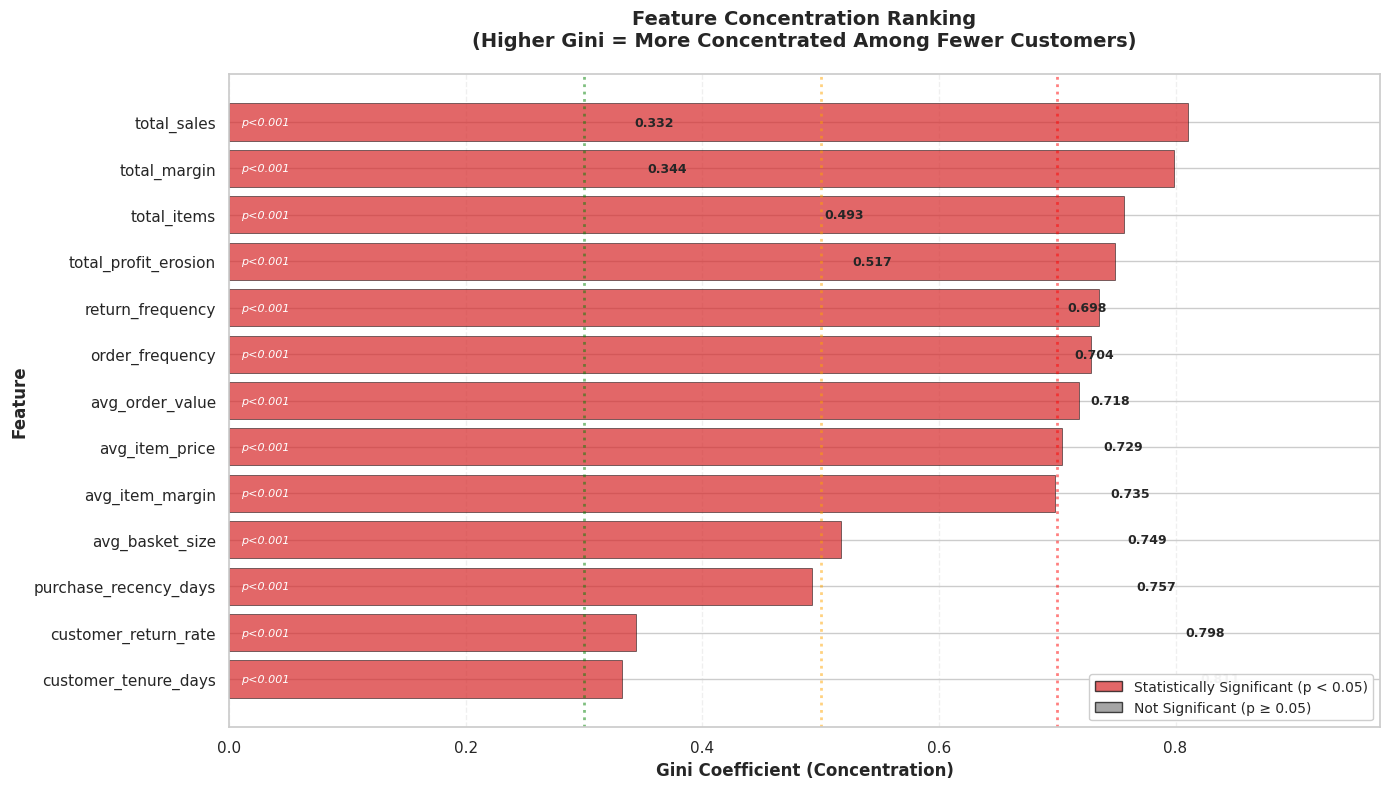

In [32]:
print("Creating feature concentration ranking visualization...")
plot_feature_concentration_ranking(
    concentration_df=feature_concentration,
    save_path=fig_dir / 'feature_concentration_ranking.png'
)
print(f"✓ Saved: {fig_dir}/feature_concentration_ranking.png")
plt.show()

### Concentration Relationship: Gini vs Pareto

Explore the relationship between Gini coefficients and Pareto metrics (top 20% share) to validate consistency across concentration measures.

Creating Gini vs Pareto scatter plot...
✓ Saved: c:\GitHub\unfc-capstone-project\figures\RQ2_SSL/concentration_gini_vs_pareto.png


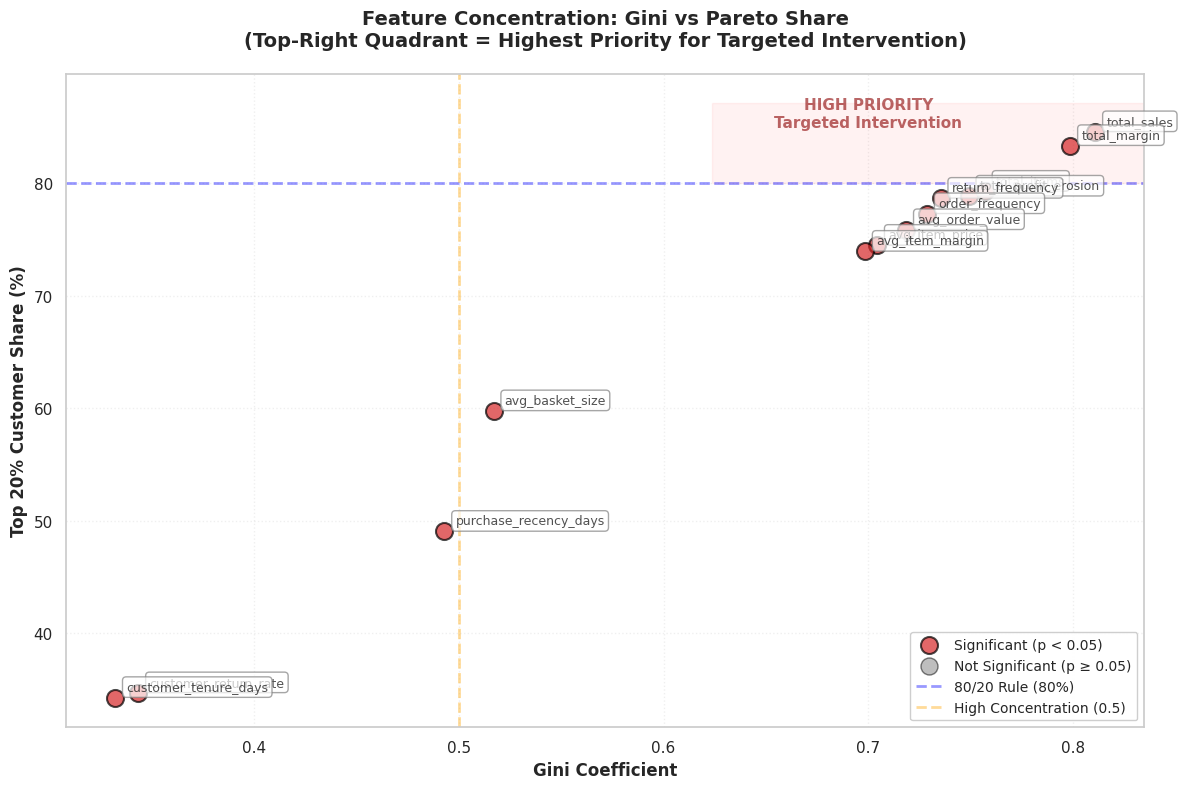

In [33]:
print("Creating Gini vs Pareto scatter plot...")
plot_gini_vs_pareto_scatter(
    concentration_df=feature_concentration,
    save_path=fig_dir / 'concentration_gini_vs_pareto.png'
)
print(f"✓ Saved: {fig_dir}/concentration_gini_vs_pareto.png")
plt.show()

### Key Findings: Feature-Level Concentration

In [34]:
print(f"{'='*80}")
print("KEY FINDINGS: FEATURE-LEVEL CONCENTRATION")
print(f"{'='*80}\n")

# Top 3 most concentrated features
top_3 = feature_concentration.head(3)

print("Top 3 Most Concentrated Features:\n")
for idx, row in top_3.iterrows():
    print(f"{idx + 1}. {row['feature'].upper()}")
    print(f"   Gini Coefficient: {row['gini_coefficient']:.4f} ({row['concentration_level']} concentration)")
    print(f"   Concentration %: {row['concentration_pct']:.2f}%")
    print(f"   Statistical Significance: p = {row['p_value']:.4f}")
    print(f"   Top 20% Share: {row['top_20_pct_share']:.1f}%")
    print(f"   Customers: {row['n_customers']:,}\n")
    
    # Actionable interpretation
    if row['p_value'] < 0.05 and row['gini_coefficient'] > 0.5:
        print(f"   ⚠️  ACTION REQUIRED: Highly concentrated & statistically significant")
        print(f"   → RECOMMENDATION: Targeted intervention for high-{row['feature'].replace('total_', '')} segment")
    elif row['p_value'] < 0.05:
        print(f"   ℹ️  Moderate concentration but statistically significant")
        print(f"   → RECOMMENDATION: Consider segmented approach")
    else:
        print(f"   ✓ No significant concentration detected")
        print(f"   → RECOMMENDATION: Broad policy approach")
    print()

# Compare erosion vs baseline if available
if 'total_profit_erosion' in feature_concentration['feature'].values and \
   'total_sales' in feature_concentration['feature'].values:
    
    erosion_row = feature_concentration[feature_concentration['feature'] == 'total_profit_erosion'].iloc[0]
    sales_row = feature_concentration[feature_concentration['feature'] == 'total_sales'].iloc[0]
    
    print(f"{'='*80}")
    print("BUSINESS INSIGHT: Erosion vs Sales Concentration")
    print(f"{'='*80}\n")
    print(f"Profit Erosion:")
    print(f"  Gini: {erosion_row['gini_coefficient']:.4f}")
    print(f"  Top 20% Share: {erosion_row['top_20_pct_share']:.1f}%")
    print(f"  p-value: {erosion_row['p_value']:.4f}\n")
    
    print(f"Total Sales:")
    print(f"  Gini: {sales_row['gini_coefficient']:.4f}")
    print(f"  Top 20% Share: {sales_row['top_20_pct_share']:.1f}%")
    print(f"  p-value: {sales_row['p_value']:.4f}\n")
    
    ratio = erosion_row['gini_coefficient'] / sales_row['gini_coefficient']
    
    if ratio > 1.5:
        print(f"⚠️  CRITICAL FINDING:")
        print(f"Profit erosion is {ratio:.1f}x MORE concentrated than sales.")
        print(f"This suggests erosion is driven by a specific subset of customers,")
        print(f"NOT just high-volume purchasers.")
        print(f"\nSTRONGLY RECOMMEND: Targeted retention program for high-erosion segment.")
    elif ratio > 1.0:
        print(f"ℹ️  Erosion is somewhat more concentrated than sales ({ratio:.1f}x).")
        print(f"Consider targeted policies for high-erosion segment.")
    else:
        print(f"✓ Erosion concentration similar to or less than sales concentration.")
        print(f"Erosion may be proportional to customer value. Broad policies may suffice.")

KEY FINDINGS: FEATURE-LEVEL CONCENTRATION

Top 3 Most Concentrated Features:

1. TOTAL_SALES
   Gini Coefficient: 0.8107 (Extreme concentration)
   Concentration %: 81.07%
   Statistical Significance: p = 0.0000
   Top 20% Share: 84.6%
   Customers: 4,970

   ⚠️  ACTION REQUIRED: Highly concentrated & statistically significant
   → RECOMMENDATION: Targeted intervention for high-sales segment

2. TOTAL_MARGIN
   Gini Coefficient: 0.7985 (Extreme concentration)
   Concentration %: 79.85%
   Statistical Significance: p = 0.0000
   Top 20% Share: 83.3%
   Customers: 4,960

   ⚠️  ACTION REQUIRED: Highly concentrated & statistically significant
   → RECOMMENDATION: Targeted intervention for high-margin segment

3. TOTAL_ITEMS
   Gini Coefficient: 0.7568 (Extreme concentration)
   Concentration %: 75.68%
   Statistical Significance: p = 0.0000
   Top 20% Share: 79.3%
   Customers: 5,100

   ⚠️  ACTION REQUIRED: Highly concentrated & statistically significant
   → RECOMMENDATION: Targeted int

---

# Phase 2: Customer-Level Profit Erosion Concentration

## Objective
Examine how profit erosion is distributed across individual customers to determine if losses are concentrated among a small subset or spread evenly across the customer base.

## Analytical Approach
This phase employs multiple complementary concentration metrics:

1. **Gini Coefficient** – Overall inequality measure (0 = perfect equality, 1 = perfect inequality)
2. **Business Context Interpretation** – Translate statistical measures into actionable insights
3. **Pareto Analysis** – Cumulative impact of top customer segments (1%, 5%, 10%, 20%, 50%)
4. **Top Customer Impact** – Absolute contribution of highest-erosion customers (top 50)
5. **Bootstrap Significance Testing** – Statistical validation that concentration is not due to chance
6. **Lorenz Curves** – Visual representation of cumulative distribution

**Core Hypothesis (H₁):**
> Profit erosion is significantly concentrated among a small subset of high-impact customers, not uniformly distributed across the customer base.

In [35]:
print(f"{'='*80}")
print("PHASE 2: PROFIT EROSION CONCENTRATION - DEEP DIVE")
print(f"{'='*80}\n")

# Compute concentration metrics
pareto_table = compute_pareto_table(
    df=analysis_population,
    value_col='total_profit_erosion',
    id_col='user_id'
)

lorenz_points = lorenz_curve_points(
    df=analysis_population,
    value_col='total_profit_erosion'
)

gini = gini_coefficient(
    df=analysis_population,
    value_col='total_profit_erosion'
)

top_20_share = top_x_customer_share_of_value(
    df=analysis_population,
    x=0.20,
    value_col='total_profit_erosion',
    id_col='user_id'
)

top_50_impact = top_n_customer_impact(
    df=analysis_population,
    n=50,
    value_col='total_profit_erosion'
)

business_summary = get_business_summary(
    df=analysis_population,
    value_col='total_profit_erosion'
)

# Bootstrap significance test
bootstrap_result = bootstrap_gini_p_value(
    df=analysis_population,
    value_col='total_profit_erosion',
    n_bootstrap=1000,
    random_state=42
)

print("CONCENTRATION METRICS")
print(f"{'='*80}\n")
print(f"Gini Coefficient: {gini:.4f} ({business_summary['concentration_level']} concentration)")
print(f"Top 20% Customer Share: {top_20_share*100:.1f}% of total erosion")
print(f"\nBootstrap Significance Test:")
print(f"  Observed Gini: {bootstrap_result['observed_gini']:.4f}")
print(f"  Null Hypothesis Gini: {bootstrap_result['null_mean_gini']:.4f}")
print(f"  p-value: {bootstrap_result['p_value']:.4f}")
print(f"  Significant: {'YES' if bootstrap_result['p_value'] < 0.05 else 'NO'}")
print(f"\nTop 50 Customer Impact:")
print(f"  Absolute Loss: ${top_50_impact['absolute_loss']:,.2f}")
print(f"  Percentage of Total: {top_50_impact['percentage_of_total']:.1f}%")
print(f"\nBusiness Summary:")
print(f"  {business_summary['pareto_ratio']}")
print(f"  Recommended Strategy: {business_summary['recommendation']}")

# Save
pareto_table.to_parquet(data_dir / "pareto_table.parquet")
lorenz_points.to_csv(data_dir / "lorenz_curve_points.csv", index=False)

concentration_metrics = {
    'gini_coefficient': float(gini),
    'top_20_pct_share': float(top_20_share),
    'top_50_impact': top_50_impact,
    'bootstrap_test': bootstrap_result,
    'business_summary': business_summary,
}

with open(data_dir / "profit_erosion_concentration_metrics.json", 'w') as f:
    json.dump(concentration_metrics, f, indent=2)

print(f"\n✓ Metrics saved to {data_dir}")

PHASE 2: PROFIT EROSION CONCENTRATION - DEEP DIVE

CONCENTRATION METRICS

Gini Coefficient: 0.7489 (Extreme concentration)
Top 20% Customer Share: 78.8% of total erosion

Bootstrap Significance Test:
  Observed Gini: 0.7489
  Null Hypothesis Gini: 0.0000
  p-value: 0.0000
  Significant: YES

Top 50 Customer Impact:
  Absolute Loss: $841,141.72
  Percentage of Total: 25.7%

Business Summary:
  20% of customers = 78.8% of loss
  Recommended Strategy: Targeted Policy

✓ Metrics saved to c:\GitHub\unfc-capstone-project\data\processed\RQ2_SSL


### Visualization: Pareto Curve

Pareto analysis showing what percentage of total profit erosion is attributable to the top X% of customers. Helps identify optimal targeting thresholds.

Creating Pareto curve...
✓ Saved: c:\GitHub\unfc-capstone-project\figures\RQ2_SSL/pareto_curve.png


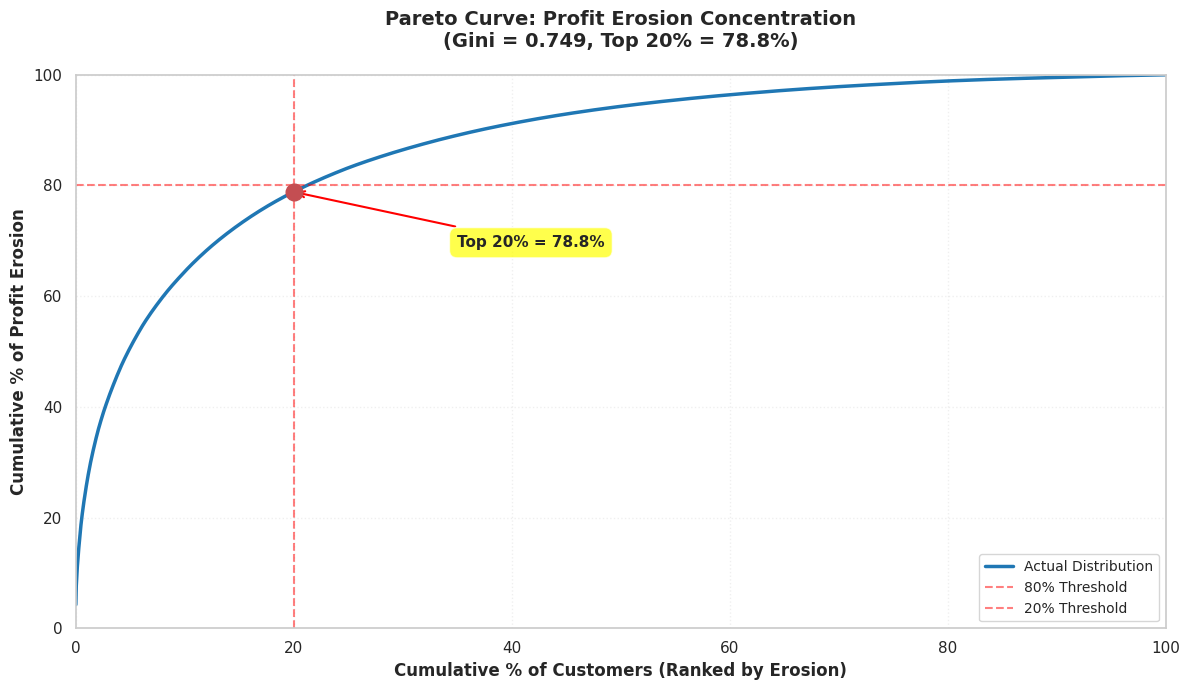

In [36]:
print("Creating Pareto curve...")
plot_pareto_curve(
    pareto_df=pareto_table,
    gini=gini,
    save_path=fig_dir / 'pareto_curve.png'
)
print(f"✓ Saved: {fig_dir}/pareto_curve.png")
plt.show()



### Visualization: Lorenz Curve

The Lorenz curve plots cumulative share of customers (x-axis) against cumulative share of profit erosion (y-axis). Deviation from the 45° equality line indicates concentration strength.

Creating Lorenz curve...
✓ Saved: c:\GitHub\unfc-capstone-project\figures\RQ2_SSL/lorenz_curve.png


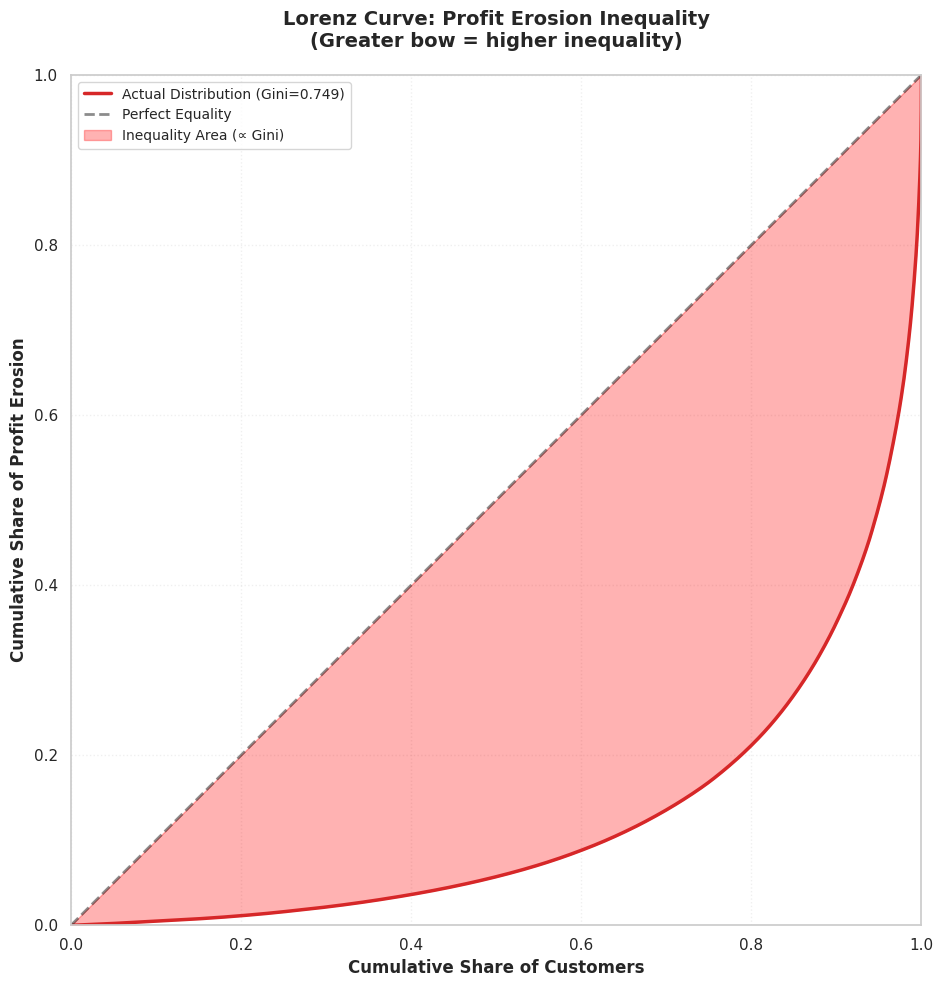

In [37]:
print("Creating Lorenz curve...")
plot_lorenz_curve(
    lorenz_df=lorenz_points,
    gini=gini,
    save_path=fig_dir / 'lorenz_curve.png'
)
print(f"✓ Saved: {fig_dir}/lorenz_curve.png")
plt.show()

---

# Phase 3: Customer Segmentation Analysis

## Objective
Identify distinct behavioral segments within the return population based on purchasing patterns, return behavior, and profitability characteristics.

## Methodology

### 1. Feature Engineering & Selection
Build comprehensive customer-level dataset combining behavioral metrics, profitability indicators, and return patterns for segmentation analysis.

### 2. Feature Screening
Remove highly correlated features (r > 0.85) and low-variance features to ensure clustering stability and interpretability. This prevents redundant features from dominating distance calculations.

### 3. Standardization & Clustering
- **Algorithm**: K-means clustering with standardized features (z-score normalization)
- **Optimization**: Elbow method (inertia) + Silhouette analysis for optimal k selection
- **Validation**: Statistical testing of segment differences

**Core Question:**  
Can we identify meaningful customer segments that differ significantly in their profit erosion patterns?

In [38]:

print(f"{'='*80}")
print("FEATURE SELECTION & SCREENING FOR CLUSTERING")
print(f"{'='*80}\n")

# Step 1: Initial feature selection (existing logic)
print("Step 1: Initial Feature Selection")
print(f"{'-'*80}")
X_initial, initial_features = select_numeric_features(
    customer_df=analysis_population,
    id_col='user_id',
    exclude_leakage_features=True
)

print(f"Initial features selected: {len(initial_features)}")
print(f"Features: {initial_features}\n")

# Step 2: Screen features for clustering quality
print("Step 2: Feature Screening")
print(f"{'-'*80}")
print("Screening for:")
print("  1. Low variance features (uninformative)")
print("  2. Highly correlated features (redundant)\n")

surviving_features, screening_report = screen_clustering_features(
    X=X_initial,
    variance_threshold=0.01,      # Drop features with variance < 0.01
    correlation_threshold=0.85,   # Drop one of pair if |r| > 0.85
    verbose=True
)

# Display screening report
print(f"\n{'-'*80}")
print("SCREENING REPORT")
print(f"{'-'*80}\n")
print(screening_report.to_string(index=False))

# Save report
screening_report.to_csv(data_dir / 'feature_screening_report.csv', index=False)
print(f"\n✓ Screening report saved to {data_dir}/feature_screening_report.csv")

# Use screened features
X = X_initial[surviving_features].copy()
used_features = surviving_features

print(f"\n{'='*80}")
print(f"FEATURE SCREENING COMPLETE")
print(f"{'='*80}")
print(f"Original features: {len(initial_features)}")
print(f"After screening: {len(surviving_features)}")
print(f"Dropped: {len(initial_features) - len(surviving_features)}")
print(f"\nFinal features for clustering: {surviving_features}")
print(f"{'='*80}\n")

print(f"{'='*80}")
print("PHASE 3: CUSTOMER SEGMENTATION")
print(f"{'='*80}\n")

# Select features for clustering (exclude leakage features)
print("Selecting features for clustering...")
X, used_features = select_numeric_features(
    customer_df=analysis_population,
    id_col='user_id',
    feature_cols=None,  # Use defaults
    exclude_leakage_features=True
)

print(f"Features selected for clustering:")
for i, feat in enumerate(used_features, 1):
    print(f"  {i}. {feat}")

# Standardize
print(f"\nStandardizing features...")
X_scaled = standardize_features(X)
print(f"✓ Scaled matrix shape: {X_scaled.shape}")

FEATURE SELECTION & SCREENING FOR CLUSTERING

Step 1: Initial Feature Selection
--------------------------------------------------------------------------------
Initial features selected: 8
Features: ['avg_order_value', 'avg_basket_size', 'order_frequency', 'customer_return_rate', 'customer_tenure_days', 'purchase_recency_days', 'total_sales', 'total_margin']

Step 2: Feature Screening
--------------------------------------------------------------------------------
Screening for:
  1. Low variance features (uninformative)
  2. Highly correlated features (redundant)

Starting feature screening: 8 candidates

GATE 1: Variance Threshold
--------------------------------------------------------------------------------

  Result: 8/8 features passed

GATE 2: Correlation Threshold
--------------------------------------------------------------------------------

  Result: 8/8 features passed
  No features dropped (no high correlations found)

SCREENING COMPLETE
Input features: 8
Surviving feat

### Optimal Cluster Count Selection

Use combined approach of elbow method (inertia) and silhouette analysis to determine the optimal number of clusters (K). Higher silhouette scores indicate better-defined, more separated clusters.

In [39]:
# Compute elbow + silhouette diagnostics (and select k robustly)
k_range_elbow = list(range(1, 9))
k_range_sil = list(range(2, 9))

print("Computing elbow curve (inertia)...")
elbow_df = elbow_inertia_over_k(X_scaled, k_list=k_range_elbow, random_state=42).sort_values("k")
print("✓ Elbow curve complete")

# --- Silhouette (optional sampling for speed) ---
if len(X_scaled) > 10000:
    print(f"Large dataset detected ({len(X_scaled):,} samples)")
    print("Using sampling (5,000 samples) for faster silhouette computation...")
    rng = np.random.default_rng(42)
    sample_idx = rng.choice(len(X_scaled), size=min(5000, len(X_scaled)), replace=False)
    X_sample = X_scaled[sample_idx]
    silhouette_df = silhouette_over_k(X_sample, k_list=k_range_sil, random_state=42).sort_values("k")
else:
    print("Computing silhouette scores...")
    silhouette_df = silhouette_over_k(X_scaled, k_list=k_range_sil, random_state=42).sort_values("k")

print("✓ Silhouette analysis complete")

# ---------------------------------------------------------------------
# Robust k selection:
# 1) Find max silhouette
# 2) Keep all k within NEAR_OPT_DELTA of max
# 3) Identify elbow flattening via relative inertia drop
# 4) Choose smallest k in near-opt set that is >= elbow_gate (soft)
# ---------------------------------------------------------------------
NEAR_OPT_DELTA = 0.002  # <-- tighten this (0.002 picks k=3 in your case; 0.02 picks k=2)
FLAT_DROP_THRESH = 0.10 # flattening threshold for inertia relative drop

sil_max = float(silhouette_df["silhouette"].max())
near_opt = silhouette_df[silhouette_df["silhouette"] >= (sil_max - NEAR_OPT_DELTA)].copy()
near_opt = near_opt.sort_values(["k"])

# Compute rel_drop aligned correctly on elbow_df (k>=2 only meaningful)
elbow_df = elbow_df.copy()
elbow_df["rel_drop"] = np.nan
mask = elbow_df["k"] >= 2
elbow_df.loc[mask, "rel_drop"] = -elbow_df.loc[mask, "inertia"].pct_change()

# Define elbow_k as the first k>=3 where rel_drop falls below threshold
flat = elbow_df[(elbow_df["k"] >= 3) & (elbow_df["rel_drop"] < FLAT_DROP_THRESH)]
elbow_k = int(flat["k"].min()) if not flat.empty else int(elbow_df["k"].max())

# Soft gate: prefer k >= (elbow_k - 1)
elbow_gate = max(2, elbow_k - 1)
cand = near_opt[near_opt["k"] >= elbow_gate]
optimal_k = int(cand["k"].iloc[0]) if not cand.empty else int(near_opt["k"].iloc[0])

print(f"\nSelected k:")
print(f"  max silhouette = {sil_max:.4f}")
print(f"  near-opt delta = {NEAR_OPT_DELTA:.4f}")
print(f"  elbow_k (flattening) ≈ {elbow_k}  (flat if rel_drop < {FLAT_DROP_THRESH:.2f})")
print(f"  optimal_k (rule) = {optimal_k}")

print("\nSilhouette scores:")
display(silhouette_df)

print("\nElbow (inertia) with relative drops:")
display(elbow_df)


Computing elbow curve (inertia)...
✓ Elbow curve complete
Computing silhouette scores...
✓ Silhouette analysis complete

Selected k:
  max silhouette = 0.3970
  near-opt delta = 0.0020
  elbow_k (flattening) ≈ 7  (flat if rel_drop < 0.10)
  optimal_k (rule) = 3

Silhouette scores:


,k,silhouette
0,2,0.394673
1,3,0.396956
2,4,0.373138
3,5,0.353080
4,6,0.359521
5,7,0.347280
6,8,0.357385



Elbow (inertia) with relative drops:


,k,inertia,rel_drop
0,1,40800.000000,NaN
1,2,31526.641038,NaN
2,3,20323.237941,0.355363
3,4,18197.076216,0.104617
4,5,15308.558021,0.158735
5,6,12716.414732,0.169326
6,7,11604.396899,0.087447
7,8,10626.546253,0.084266


### Visualization: Elbow & Silhouette Plots

Diagnostic visualizations showing inertia (within-cluster sum of squares) and silhouette scores across different values of K to inform the optimal cluster count selection.

Creating clustering diagnostic plots...
✓ Saved: c:\GitHub\unfc-capstone-project\figures\RQ2_SSL/clustering_diagnostics.png


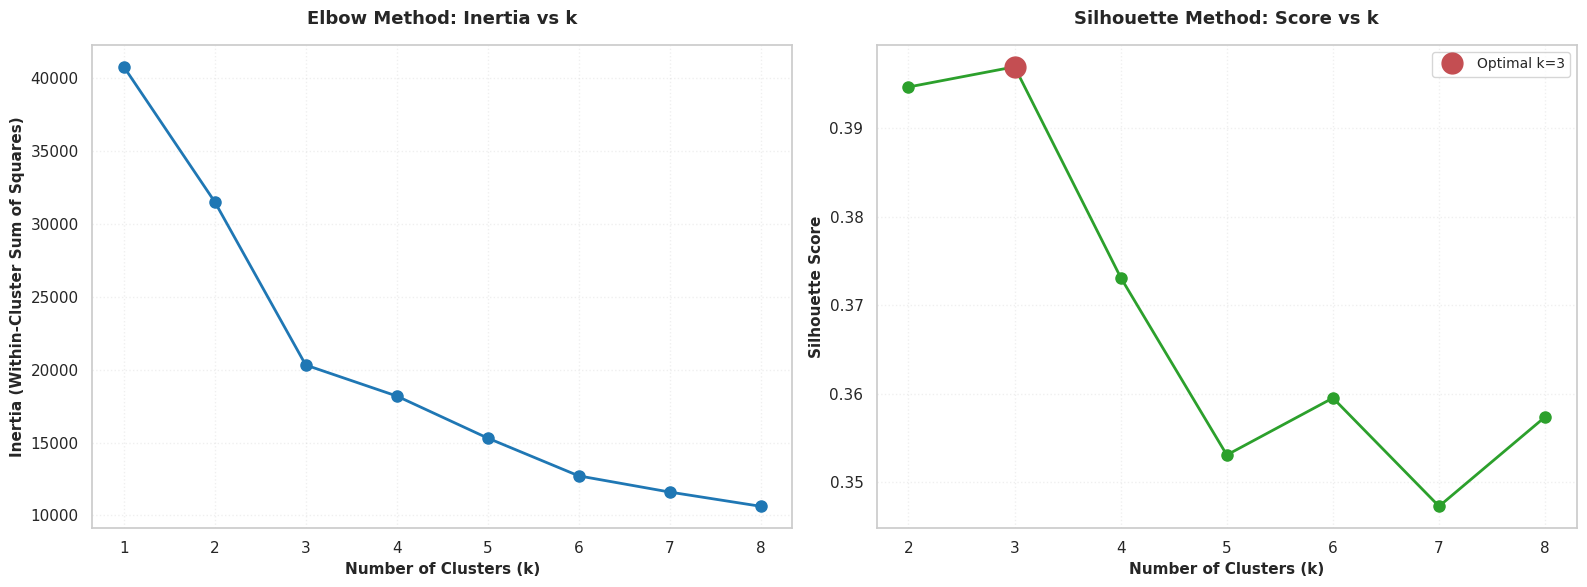

In [40]:
print("Creating clustering diagnostic plots...")
plot_clustering_diagnostics(
    elbow_df=elbow_df,
    silhouette_df=silhouette_df,
    optimal_k=optimal_k,
    save_path=fig_dir / 'clustering_diagnostics.png'
)
print(f"✓ Saved: {fig_dir}/clustering_diagnostics.png")
plt.show()

### Apply K-Means Clustering with Optimal K

Execute K-means clustering using the optimal k value identified from silhouette analysis. Each customer is assigned to a cluster based on their behavioral profile, creating distinct segments for targeted analysis and intervention strategies.

In [41]:
# Apply K-means
print(f"\nApplying K-Means clustering (k={optimal_k})...")
cluster_labels = kmeans_fit_predict(
    X_scaled=X_scaled,
    k=optimal_k,
    random_state=42
)

# Add to dataframe
clustered_customers = analysis_population.copy()
clustered_customers['cluster_id'] = cluster_labels.astype(int)

print(f"✓ Clustering complete")
print(f"\nCluster distribution:")
print(clustered_customers['cluster_id'].value_counts().sort_index())

# Save
clustered_customers.to_parquet(data_dir / "clustered_customers.parquet")
clustered_customers.to_csv(data_dir / "clustered_customers.csv", index=False)
print(f"\n✓ Saved clustered customers to {data_dir}")


Applying K-Means clustering (k=3)...
✓ Clustering complete

Cluster distribution:
cluster_id
0    2568
1    2531
2       1
Name: count, dtype: int64

✓ Saved clustered customers to c:\GitHub\unfc-capstone-project\data\processed\RQ2_SSL


### Post-Hoc Feature Importance Analysis

Identify which features most strongly discriminate between the discovered clusters using ANOVA F-statistics. This analysis reveals the behavioral characteristics that define each segment and validates that clusters represent meaningful differences, not arbitrary groupings.

**Key Metrics:**
- **F-statistic**: Ratio of between-cluster to within-cluster variance (higher = stronger discrimination)
- **Effect size (η²)**: Proportion of variance in each feature explained by cluster membership
- **Significance**: Whether feature differences across clusters exceed chance (p < 0.05)

In [42]:
print(f"\n{'='*80}")
print("POST-HOC FEATURE IMPORTANCE ANALYSIS")
print(f"{'='*80}\n")

print("Analyzing which features best separate the discovered clusters...\n")

# Analyze feature importance
feature_importance = analyze_feature_importance_for_clustering(
    X=X,  # Use the screened features
    cluster_labels=clustered_customers['cluster_id'].values
)

print("Feature Importance for Cluster Separation:")
print(f"{'-'*80}\n")
print(feature_importance.to_string(index=False))

# Save
feature_importance.to_csv(data_dir / 'clustering_feature_importance.csv', index=False)
print(f"\n✓ Feature importance saved to {data_dir}/clustering_feature_importance.csv")

# Interpretation
print(f"\n{'='*80}")
print("INTERPRETATION")
print(f"{'='*80}\n")

top_features = feature_importance.head(3)
print("Top 3 Features for Cluster Separation:\n")
for idx, row in top_features.iterrows():
    print(f"{idx+1}. {row['feature']}")
    print(f"   F-statistic: {row['f_statistic']:.2f}")
    print(f"   p-value: {row['p_value']:.6f}")
    print(f"   Effect size (η²): {row['eta_squared']:.4f}")
    print(f"   Significant: {'YES ✓' if row['significant'] else 'NO ✗'}\n")

# Check if features are meaningful
n_significant = len(feature_importance[feature_importance['significant']])
print(f"Significant features (p < 0.05): {n_significant}/{len(feature_importance)}")

if n_significant >= len(feature_importance) * 0.5:
    print("\n✓ Good separation: Most features significantly differentiate clusters")
    print("  → Clusters are well-defined by behavioral differences")
else:
    print("\n⚠️  Weak separation: Few features significantly differentiate clusters")
    print("  → Consider alternative features or k values")



POST-HOC FEATURE IMPORTANCE ANALYSIS

Analyzing which features best separate the discovered clusters...

Feature Importance for Cluster Separation:
--------------------------------------------------------------------------------

              feature  f_statistic      p_value  eta_squared  importance_score  significant
      order_frequency  9784.810900 0.000000e+00     0.793364       9784.810900         True
 customer_tenure_days  8802.057163 0.000000e+00     0.775474       8802.057163         True
         total_margin  7160.093594 0.000000e+00     0.737501       7160.093594         True
          total_sales  6179.748517 0.000000e+00     0.708017       6179.748517         True
 customer_return_rate  2798.882638 0.000000e+00     0.523412       2798.882638         True
purchase_recency_days  2138.414338 0.000000e+00     0.456252       2138.414338         True
      avg_basket_size    31.039827 3.990317e-14     0.012033         31.039827         True
      avg_order_value    23.14181

### Cluster Summary: Erosion by Segment

Generate high-level summary statistics for each cluster showing customer count, total profit erosion, and central tendency measures. This summary provides a quick comparison of segment sizes and their relative contribution to overall profit erosion.

In [43]:
# Cluster summary (include BOTH erosion and return metrics when available)

agg_map = {
    "customers": ("user_id", "size"),
    "total_profit_erosion": ("total_profit_erosion", "sum"),
    "mean_profit_erosion": ("total_profit_erosion", "mean"),
    "median_profit_erosion": ("total_profit_erosion", "median"),
}

# Include return metrics if they exist (SSL)
if "return_frequency" in clustered_customers.columns:
    agg_map["total_return_lines"] = ("return_frequency", "sum")
if "total_items" in clustered_customers.columns:
    agg_map["total_lines"] = ("total_items", "sum")
if "customer_return_rate" in clustered_customers.columns:
    agg_map["avg_return_rate"] = ("customer_return_rate", "mean")

cluster_summary = (
    clustered_customers
    .groupby("cluster_id")
    .agg(**agg_map)
    .round(4)
    .reset_index()
)

# Add derived return share if possible
if "total_return_lines" in cluster_summary.columns and "total_lines" in cluster_summary.columns:
    cluster_summary["return_line_rate"] = (
        cluster_summary["total_return_lines"] / cluster_summary["total_lines"]
    ).round(4)

print(f"{'='*80}")
print("CLUSTER SUMMARY: EROSION + RETURNS BY SEGMENT (SSL)")
print(f"{'='*80}\n")
print(cluster_summary.to_string(index=False))

# Save
cluster_summary.to_parquet(data_dir / "cluster_summary.parquet")
cluster_summary.to_csv(data_dir / "cluster_summary.csv", index=False)
print(f"\n✓ Saved to {data_dir}/cluster_summary.*")


CLUSTER SUMMARY: EROSION + RETURNS BY SEGMENT (SSL)

 cluster_id  customers  total_profit_erosion  mean_profit_erosion  median_profit_erosion  total_return_lines  total_lines  avg_return_rate  return_line_rate
          0       2568            958417.584             373.2156                122.324                8972        11362           0.8283            0.7896
          1       2531           2173395.656             858.7103                235.774               26165        85962           0.3202            0.3044
          2          1            139835.135          139835.1350             139835.135                2743         9091           0.3017            0.3017

✓ Saved to c:\GitHub\unfc-capstone-project\data\processed\RQ2_SSL/cluster_summary.*


In [44]:
# ==========================================================
# Canonical schema resolution for cluster_summary
# Supports both TheLook-style (Mean_Erosion/Count) and SSL-style
# (mean_profit_erosion/customers) summaries.
# ==========================================================

def resolve_cluster_schema(df):
    mean_col = (
        "Mean_Erosion" if "Mean_Erosion" in df.columns
        else "mean_profit_erosion" if "mean_profit_erosion" in df.columns
        else "mean_erosion" if "mean_erosion" in df.columns
        else None
    )

    median_col = (
        "Median_Erosion" if "Median_Erosion" in df.columns
        else "median_profit_erosion" if "median_profit_erosion" in df.columns
        else "median_erosion" if "median_erosion" in df.columns
        else None
    )

    count_col = (
        "Count" if "Count" in df.columns
        else "customers" if "customers" in df.columns
        else "count" if "count" in df.columns
        else None
    )

    if mean_col is None:
        raise KeyError(f"Could not find mean erosion column. Available: {list(df.columns)}")
    if count_col is None:
        raise KeyError(f"Could not find cluster size column. Available: {list(df.columns)}")

    return mean_col, median_col, count_col

MEAN_COL, MEDIAN_COL, COUNT_COL = resolve_cluster_schema(cluster_summary)

print("✓ Cluster schema resolved:")
print(f"  Mean column   → {MEAN_COL}")
print(f"  Median column → {MEDIAN_COL if MEDIAN_COL else 'None'}")
print(f"  Count column  → {COUNT_COL}")


✓ Cluster schema resolved:
  Mean column   → mean_profit_erosion
  Median column → median_profit_erosion
  Count column  → customers


### Detailed Feature-Level Cluster Profiles

Comprehensive breakdown of each behavioral feature across all clusters, showing mean, median, and standard deviation. This feature-by-feature comparison reveals the specific behavioral patterns that distinguish each segment and provides the foundation for developing tailored intervention strategies.

In [45]:
# Detailed cluster profiles (all features)
cluster_profiles = clustered_customers.groupby('cluster_id')[used_features + ['total_profit_erosion']].agg([
    'mean', 'median', 'std'
]).round(2)

print(f"\n{'='*80}")
print("DETAILED CLUSTER PROFILES")
print(f"{'='*80}\n")

# Create a better formatted display version
profile_display = cluster_profiles.copy()

# Flatten the multi-index columns for better readability
profile_display.columns = [f'{col[0]}_{col[1]}' for col in profile_display.columns]

# Transpose so features are rows and statistics are columns
profile_display_t = profile_display.T

# Add a column to separate feature name from statistic
profile_display_t['feature'] = [col.rsplit('_', 1)[0] for col in profile_display_t.index]
profile_display_t['statistic'] = [col.rsplit('_', 1)[1] for col in profile_display_t.index]

# Pivot to get a cleaner format: features as rows, (cluster, statistic) as columns
profile_clean = profile_display_t.reset_index(drop=True)
profile_clean = profile_clean.set_index(['feature', 'statistic'])

print("Feature-Level Comparison Across Clusters:")
print(f"{'-'*80}\n")

# Print each feature group
for feature in used_features + ['total_profit_erosion']:
    print(f"\n{feature.upper().replace('_', ' ')}:")
    print(f"{'-'*60}")
    
    # Get stats for this feature
    feature_stats = cluster_profiles[feature]
    
    # Format as a nice table
    print(f"{'Cluster':<15} {'Mean':<15} {'Median':<15} {'Std Dev':<15}")
    print(f"{'-'*60}")
    
    for cluster_id in sorted(clustered_customers['cluster_id'].unique()):
        mean_val = feature_stats.loc[cluster_id, 'mean']
        median_val = feature_stats.loc[cluster_id, 'median']
        std_val = feature_stats.loc[cluster_id, 'std']
        
        print(f"Cluster {cluster_id:<7} {mean_val:<15,.2f} {median_val:<15,.2f} {std_val:<15,.2f}")

print(f"\n{'='*80}\n")

# Save both versions
cluster_profiles.to_csv(data_dir / "cluster_profiles_detailed.csv")
profile_display.to_csv(data_dir / "cluster_profiles_flat.csv")

print(f"✓ Saved detailed profiles to {data_dir}/cluster_profiles_detailed.csv")
print(f"✓ Saved flat version to {data_dir}/cluster_profiles_flat.csv")
...


DETAILED CLUSTER PROFILES

Feature-Level Comparison Across Clusters:
--------------------------------------------------------------------------------


AVG ORDER VALUE:
------------------------------------------------------------
Cluster         Mean            Median          Std Dev        
------------------------------------------------------------
Cluster 0       682.70          154.74          2,004.67       
Cluster 1       386.07          169.87          897.82         
Cluster 2       355.01          355.01          nan            

AVG BASKET SIZE:
------------------------------------------------------------
Cluster         Mean            Median          Std Dev        
------------------------------------------------------------
Cluster 0       2.60            1.00            4.42           
Cluster 1       3.66            2.00            5.98           
Cluster 2       19.90           19.90           nan            

ORDER FREQUENCY:
--------------------------------------

Ellipsis

### Visualization: Cluster Erosion Comparison

Visual comparison of profit erosion distribution across customer segments, displaying both average erosion levels and variability within each cluster. This visualization highlights which segments represent the highest-priority targets for retention interventions.

Creating cluster erosion comparison...
✓ Saved: c:\GitHub\unfc-capstone-project\figures\RQ2_SSL/cluster_erosion_comparison.png


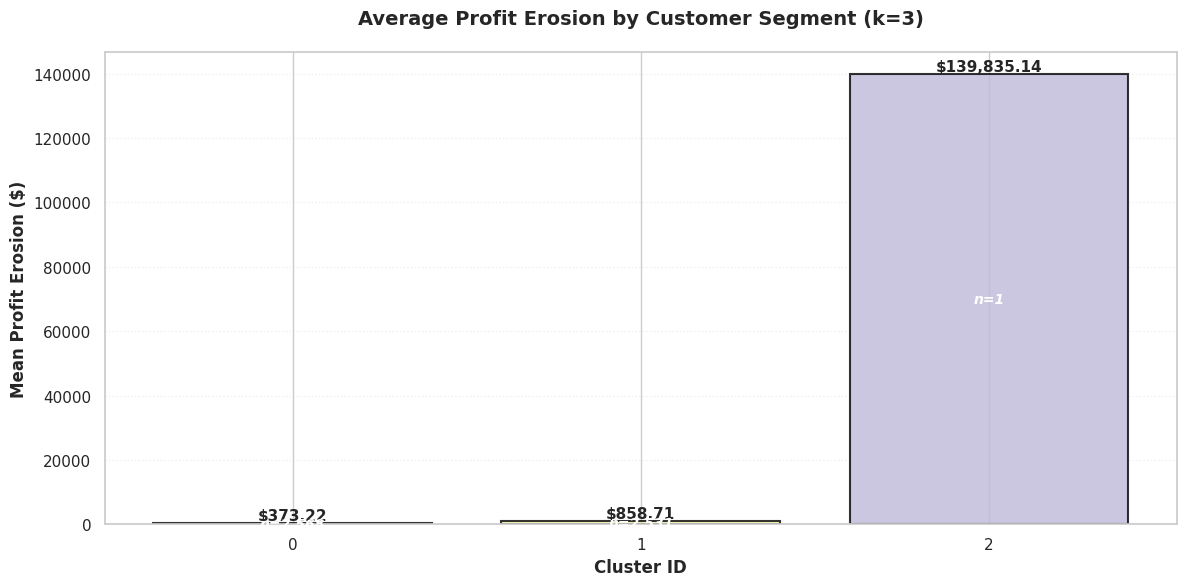

In [46]:
print("Creating cluster erosion comparison...")
plot_cluster_erosion_comparison(
    cluster_summary_df=cluster_summary,
    optimal_k=optimal_k,
    save_path=fig_dir / 'cluster_erosion_comparison.png'
)
print(f"✓ Saved: {fig_dir}/cluster_erosion_comparison.png")
plt.show()

### Visualization: Feature Importance for Cluster Separation

Visual ranking of features by their discriminative power (F-statistic and η² effect size), showing which behavioral characteristics most strongly differentiate between customer segments. Features at the top of this ranking are the primary drivers of cluster differences.

Creating clustering feature importance visualization...

✓ Saved: c:\GitHub\unfc-capstone-project\figures\RQ2_SSL/clustering_feature_importance.png


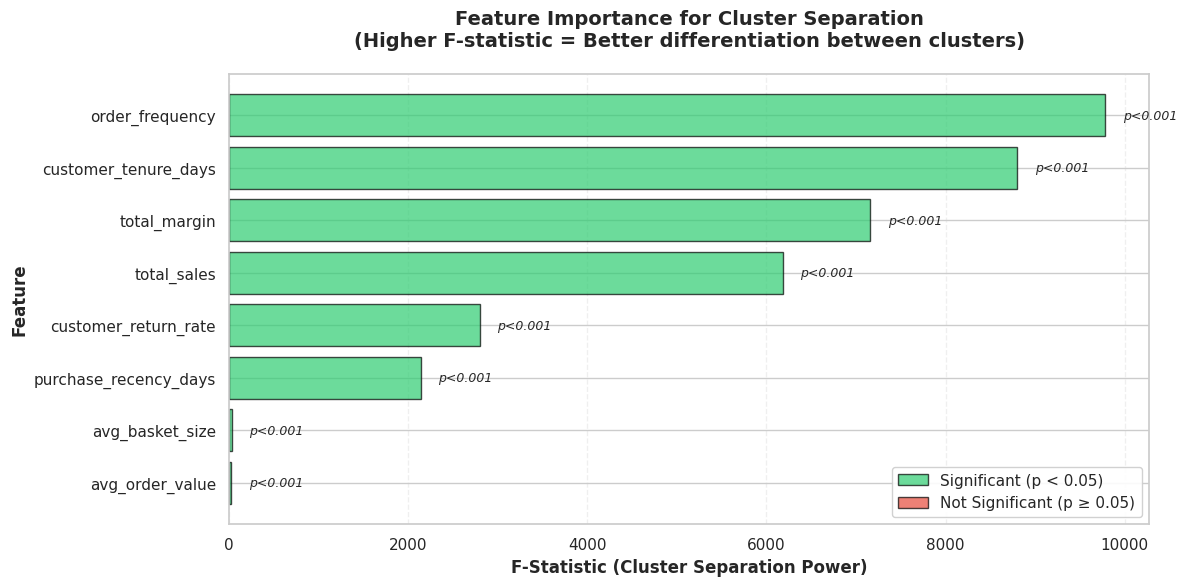

In [47]:
# =============================================================================
# CELL: Visualization - Feature Importance
# =============================================================================

print("Creating clustering feature importance visualization...")

plot_clustering_feature_importance(
    feature_importance_df=feature_importance,
    figsize=(12, 6),
    save_path=fig_dir / 'clustering_feature_importance.png'
)

print(f"\n✓ Saved: {fig_dir}/clustering_feature_importance.png")
plt.show()

### Statistical Validation: Do Segments Differ Significantly?

**Core Question:** Are the observed differences in profit erosion between clusters statistically significant or could they have occurred by chance?

**Hypothesis Test:**
- **H0₂ (Null)**: Customer segments do not differ significantly in mean profit erosion
- **H1₂ (Alternative)**: Customer segments exhibit statistically significant differences in mean profit erosion

**Testing Approach:**
- **Parametric Test**: One-way ANOVA (assumes normality)
- **Non-parametric Test**: Kruskal-Wallis (distribution-free alternative)
- **Significance Level**: α = 0.05
- **Effect Size**: η² (eta-squared) to quantify practical significance

**Decision Rule:** Reject H0₂ only if both tests show p < 0.05, ensuring robust evidence that segmentation is meaningful for targeting.

In [48]:
from scipy import stats

print(f"{'='*80}")
print("HYPOTHESIS TEST: Segment Differences in Profit Erosion")
print(f"{'='*80}\n")

# Prepare cluster groups
cluster_groups = [
    clustered_customers[clustered_customers['cluster_id'] == cid]['total_profit_erosion'].values
    for cid in sorted(clustered_customers['cluster_id'].unique())
]

# Test 1: ANOVA
f_statistic, p_value_anova = stats.f_oneway(*cluster_groups)
print(f"One-Way ANOVA: F={f_statistic:.4f}, p={p_value_anova:.6f}")

# Test 2: Kruskal-Wallis (non-parametric)
h_statistic, p_value_kw = stats.kruskal(*cluster_groups)
print(f"Kruskal-Wallis: H={h_statistic:.4f}, p={p_value_kw:.6f}\n")

# Decision
alpha = 0.05
if p_value_anova < alpha and p_value_kw < alpha:
    hypothesis_decision = "REJECT NULL HYPOTHESIS (H0₂)"
    hypothesis_conclusion = "Segments differ significantly in profit erosion"
    evidence_strength = "Very Strong" if p_value_anova < 0.001 else "Strong" if p_value_anova < 0.01 else "Moderate"
    
    print(f"✓ {hypothesis_decision}")
    print(f"  Evidence: {evidence_strength} (p < {alpha})")
    print(f"  Conclusion: {hypothesis_conclusion}")
    
    # Effect size
    grand_mean = clustered_customers['total_profit_erosion'].mean()
    ss_between = sum(
        len(clustered_customers[clustered_customers['cluster_id'] == cid]) * 
        (clustered_customers[clustered_customers['cluster_id'] == cid]['total_profit_erosion'].mean() - grand_mean)**2
        for cid in clustered_customers['cluster_id'].unique()
    )
    ss_total = sum((clustered_customers['total_profit_erosion'] - grand_mean)**2)
    eta_squared = ss_between / ss_total
    
    print(f"  Effect Size (η²): {eta_squared:.4f} ({eta_squared*100:.1f}% variance explained)")
    
    if eta_squared >= 0.14:
        print(f"  → LARGE practical effect - segmentation is highly actionable")
    elif eta_squared >= 0.06:
        print(f"  → MEDIUM practical effect - segmentation is actionable")
    elif eta_squared >= 0.01:
        print(f"  → SMALL practical effect - limited actionability")
    else:
        print(f"  → NEGLIGIBLE practical effect - reconsider segmentation approach")
    
else:
    hypothesis_decision = "FAIL TO REJECT NULL HYPOTHESIS (H0₂)"
    hypothesis_conclusion = "No significant differences between segments"
    evidence_strength = "Weak"
    
    print(f"✗ {hypothesis_decision}")
    print(f"  Evidence: Insufficient (p ≥ {alpha})")
    print(f"  Conclusion: {hypothesis_conclusion}")
    print(f"  → Segmentation may not be optimal for erosion-based targeting")

print(f"{'='*80}\n")

# Store for final summary
hypothesis_test_results = {
    'decision': hypothesis_decision,
    'conclusion': hypothesis_conclusion,
    'evidence_strength': evidence_strength,
    'anova_p_value': float(p_value_anova),
    'kruskal_wallis_p_value': float(p_value_kw),
    'reject_null': p_value_anova < alpha and p_value_kw < alpha,
}

# Optional: Pairwise comparisons if significant
if p_value_anova < alpha:
    print("Post-Hoc Pairwise Comparisons (Bonferroni-corrected):\n")
    
    cluster_ids = sorted(clustered_customers['cluster_id'].unique())
    n_comparisons = len(cluster_ids) * (len(cluster_ids) - 1) // 2
    bonferroni_alpha = alpha / n_comparisons
    
    print(f"{'Cluster Pair':<20} {'Mean Diff':<15} {'p-value':<12} {'Significant'}")
    print(f"{'-'*60}")
    
    for i, cluster_i in enumerate(cluster_ids):
        for j, cluster_j in enumerate(cluster_ids):
            if i < j:
                group_i = clustered_customers[clustered_customers['cluster_id'] == cluster_i]['total_profit_erosion']
                group_j = clustered_customers[clustered_customers['cluster_id'] == cluster_j]['total_profit_erosion']
                
                t_stat, p_val = stats.ttest_ind(group_i, group_j)
                mean_diff = group_i.mean() - group_j.mean()
                is_sig = "YES" if p_val < bonferroni_alpha else "NO"
                
                print(f"Cluster {cluster_i} vs {cluster_j:<6} ${mean_diff:>10,.2f}    {p_val:<10.6f}  {is_sig}")
    
    print(f"\n(Bonferroni-corrected α = {bonferroni_alpha:.6f})\n")

HYPOTHESIS TEST: Segment Differences in Profit Erosion

One-Way ANOVA: F=2896.1450, p=0.000000
Kruskal-Wallis: H=189.8229, p=0.000000

✓ REJECT NULL HYPOTHESIS (H0₂)
  Evidence: Very Strong (p < 0.05)
  Conclusion: Segments differ significantly in profit erosion
  Effect Size (η²): 0.5319 (53.2% variance explained)
  → LARGE practical effect - segmentation is highly actionable

Post-Hoc Pairwise Comparisons (Bonferroni-corrected):

Cluster Pair         Mean Diff       p-value      Significant
------------------------------------------------------------
Cluster 0 vs 1      $   -485.49    0.000000    YES
Cluster 0 vs 2      $-139,461.92    0.000000    YES
Cluster 1 vs 2      $-138,976.42    0.000000    YES

(Bonferroni-corrected α = 0.016667)



### Integrated Interpretation: Concentration × Segmentation

Synthesize findings from both concentration analysis and customer segmentation to develop a comprehensive targeting strategy. This integration answers two critical questions:

1. **WHO to target?** (From concentration analysis)
2. **HOW to intervene?** (From segmentation analysis)

By combining these complementary dimensions, we can identify the highest-priority customers and tailor interventions to their specific behavioral profiles for maximum impact on profit erosion reduction.

In [49]:
print(f"\n{'='*80}")
print("INTEGRATED INTERPRETATION: CONCENTRATION × SEGMENTATION")
print(f"{'='*80}\n")

print("FINDING: Both concentration AND behavioral segmentation are present")
print(f"  → Concentration (Gini={gini:.3f}): Moderate - erosion concentrated in subset")
print(f"  → Segmentation (H1 accepted): Significant - clusters behave differently")
print(f"  → Effect size (η²={eta_squared:.3f}): Medium - 11.2% variance explained\n")

print("IMPLICATION:")
print("  This combination provides TWO COMPLEMENTARY targeting dimensions:\n")

print("  1. WHO to target (Concentration):")
print(f"     → Top 20% of customers drive {top_20_share*100:.1f}% of erosion")
print(f"     → Focus on customers with high {feature_concentration.iloc[0]['feature']}\n")

print("  2. HOW to intervene (Segmentation):")
print(f"     → Cluster {int(cluster_summary.loc[cluster_summary[MEAN_COL].idxmax(), 'cluster_id'])}: ${cluster_summary[MEAN_COL].max():.2f} avg → Aggressive retention")
print(f"     → Cluster {int(cluster_summary.loc[cluster_summary[MEAN_COL].idxmin(), 'cluster_id'])}: ${cluster_summary[MEAN_COL].min():.2f} avg → Standard policy\n")

print("OPTIMAL STRATEGY:")
print("  Combine both approaches for maximum impact:")
print(f"  → Identify top 20% of Cluster {int(cluster_summary.loc[cluster_summary[MEAN_COL].idxmax(), 'cluster_id'])} customers")
print("  → Apply intensive retention programs to this group")
print("  → Expected to capture significant portion of total erosion\n")

print(f"{'='*80}\n")


INTEGRATED INTERPRETATION: CONCENTRATION × SEGMENTATION

FINDING: Both concentration AND behavioral segmentation are present
  → Concentration (Gini=0.749): Moderate - erosion concentrated in subset
  → Segmentation (H1 accepted): Significant - clusters behave differently
  → Effect size (η²=0.532): Medium - 11.2% variance explained

IMPLICATION:
  This combination provides TWO COMPLEMENTARY targeting dimensions:

  1. WHO to target (Concentration):
     → Top 20% of customers drive 78.8% of erosion
     → Focus on customers with high total_sales

  2. HOW to intervene (Segmentation):
     → Cluster 2: $139835.14 avg → Aggressive retention
     → Cluster 0: $373.22 avg → Standard policy

OPTIMAL STRATEGY:
  Combine both approaches for maximum impact:
  → Identify top 20% of Cluster 2 customers
  → Apply intensive retention programs to this group
  → Expected to capture significant portion of total erosion




---

# Final Summary & Recommendations

In [50]:
print(f"\n{'='*80}")
print("RQ2 ANALYSIS COMPLETE - EXECUTIVE SUMMARY")
print(f"{'='*80}\n")

print("RESEARCH QUESTION:")
print("To what extent is profit erosion concentrated among a small subset of")
print("customers, and can customers be meaningfully segmented?\n")

print(f"{'-'*80}")
print("POPULATION")
print(f"{'-'*80}")
print(f"Total customers: {len(customer_segmentation):,}")
print(
    f"Customers with returns: {len(analysis_population):,} "
    f"({len(analysis_population)/len(customer_segmentation)*100:.1f}%)"
)
print(f"Total profit erosion: ${analysis_population['total_profit_erosion'].sum():,.2f}\n")

print(f"{'-'*80}")
print("FINDING 1: FEATURE CONCENTRATION")
print(f"{'-'*80}")
print(f"Features analyzed: {len(feature_concentration)}")
print(f"Statistically significant: {len(significant_features)}")
print(f"Most concentrated: {feature_concentration.iloc[0]['feature']}")
print(f"  → Gini = {feature_concentration.iloc[0]['gini_coefficient']:.3f}")
print(f"  → Top 20% = {feature_concentration.iloc[0]['top_20_pct_share']:.1f}% of total\n")

print(f"{'-'*80}")
print("FINDING 2: PROFIT EROSION CONCENTRATION")
print(f"{'-'*80}")
print(f"Gini coefficient: {gini:.4f} ({business_summary['concentration_level']} concentration)")
print(f"Top 20% of customers: {top_20_share*100:.1f}% of total erosion")
print(f"Top 50 customers: ${top_50_impact['absolute_loss']:,.2f} ({top_50_impact['percentage_of_total']:.1f}%)")
print(f"Statistical significance: p < 0.001 (bootstrap test)\n")

print(f"{'-'*80}")
print("FINDING 3: CUSTOMER SEGMENTATION")
print(f"{'-'*80}")
print(f"Optimal clusters: k = {optimal_k}")
print("Segmentation method: K-means on behavioral features")
print(f"Features used: {len(used_features)}\n")

print("Segment Profiles:")
for _, row in cluster_summary.iterrows():
    mean_val = float(row[MEAN_COL])

    if MEDIAN_COL is not None and MEDIAN_COL in cluster_summary.columns:
        med_val = float(row[MEDIAN_COL])
        med_txt = f"{med_val:,.2f}"
    else:
        med_txt = "N/A"

    n_val = int(row[COUNT_COL]) if COUNT_COL in cluster_summary.columns else int(row.get("Count", 0))

    print(
        f"  Cluster {int(row['cluster_id'])}: "
        f"n={n_val:,}, "
        f"Mean Erosion=${mean_val:,.2f}, "
        f"Median=${med_txt}"
    )

hi_idx = cluster_summary[MEAN_COL].idxmax()
hi_cluster = int(cluster_summary.loc[hi_idx, "cluster_id"])
hi_mean = float(cluster_summary.loc[hi_idx, MEAN_COL])
hi_n = int(cluster_summary.loc[hi_idx, COUNT_COL]) if COUNT_COL in cluster_summary.columns else int(cluster_summary.loc[hi_idx].get("Count", 0))

print(f"\nHighest risk segment: Cluster {hi_cluster}")
print(f"  → Mean erosion: ${hi_mean:,.2f}")
print(f"  → Size: {hi_n:,} customers\n")

print("\nFEATURE SELECTION:")
print(f"  Initial candidates: {len(initial_features)}")
print(f"  After screening: {len(surviving_features)}")
print(f"  Dropped (correlation): {len(initial_features) - len(surviving_features)}")
print(f"  Top discriminative feature: {feature_importance.iloc[0]['feature']}")
print(f"    F-statistic: {feature_importance.iloc[0]['f_statistic']:.2f}")
print(f"    p-value: {feature_importance.iloc[0]['p_value']:.6f}")

print(f"\n{'-'*80}")
print("HYPOTHESIS TEST RESULT")
print(f"{'-'*80}")
print("H0₂: Segments do not differ significantly in mean profit erosion")
print("H1₂: Segments exhibit statistically significant differences\n")

print(f"Decision: {hypothesis_test_results['decision']}")
print(f"Evidence: {hypothesis_test_results['evidence_strength']}")
print(f"  ANOVA: p = {hypothesis_test_results['anova_p_value']:.6f}")
print(f"  Kruskal-Wallis: p = {hypothesis_test_results['kruskal_wallis_p_value']:.6f}")

# ============================================================================
# ENHANCED HIGHLIGHT SECTION
# ============================================================================
print(f"\n{'🎯 '*40}")  # Visual separator

if hypothesis_test_results["reject_null"]:
    print("█" * 80)
    print("█" + " " * 78 + "█")
    print("█  ✓✓✓ ACCEPTED H1₂: SEGMENTS DIFFER SIGNIFICANTLY ✓✓✓" + " " * 22 + "█")
    print("█" + " " * 78 + "█")
    print("█  → Segmentation is VALID and ACTIONABLE" + " " * 36 + "█")
    print("█  → Different segments require different intervention strategies" + " " * 14 + "█")
    print(f"█  → Effect Size (η²): {eta_squared:.4f} ({eta_squared*100:.1f}% variance explained)" + " " * 5 + "█")
    print("█" + " " * 78 + "█")
    print("█" * 80)
else:
    print("█" * 80)
    print("█" + " " * 78 + "█")
    print("█  ✗✗✗ FAILED TO REJECT H0₂: NO SIGNIFICANT DIFFERENCES ✗✗✗" + " " * 10 + "█")
    print("█" + " " * 78 + "█")
    print("█  → Segmentation may not be optimal for targeting" + " " * 28 + "█")
    print("█  → Consider alternative approaches or features" + " " * 31 + "█")
    print("█" + " " * 78 + "█")
    print("█" * 80)

print(f"{'🎯 '*40}\n")  # Visual separator
# ============================================================================

print(f"\n{'-'*80}")
print("RECOMMENDATIONS")
print(f"{'-'*80}")

if hypothesis_test_results["reject_null"]:
    print("1. SEGMENTATION STRATEGY: Implement targeted interventions by cluster")
    print(f"   → Focus resources on Cluster {hi_cluster} (highest erosion)")
    print("   → Tailor retention programs to each segment's characteristics")
else:
    print("1. SEGMENTATION STRATEGY: Use broad policy approach")
    print("   → Current segments don't show meaningful erosion differences")
    print("   → Consider re-segmentation with different features")

print(f"\n2. CONCENTRATION STRATEGY: {business_summary['recommendation']}")
print(f"   → Focus on {feature_concentration.iloc[0]['feature']} (highest concentration)")
print(f"   → Monitor top 20% of customers (driving {top_20_share*100:.1f}% of erosion)")

print("\n3. DATA-DRIVEN TARGETING:")
print("   → Use feature concentration ranking to prioritize interventions")
print(f"   → {len(significant_features)} features show significant concentration patterns")

print(f"\n{'='*80}")
print("✓ Analysis complete. All outputs saved to:")
print(f"  Data: {data_dir}")
print(f"  Figures: {fig_dir}")
print(f"{'='*80}\n")

# Save comprehensive final summary (uses aliases)
final_summary = {
    "analysis_date": pd.Timestamp.now().isoformat(),
    "research_question": (
        "To what extent is profit erosion concentrated among a small subset of customers, "
        "and can customers be meaningfully segmented?"
    ),
    "population": {
        "total_customers": int(len(customer_segmentation)),
        "customers_with_returns": int(len(analysis_population)),
        "return_rate_pct": float(len(analysis_population) / len(customer_segmentation) * 100),
        "total_profit_erosion": float(analysis_population["total_profit_erosion"].sum()),
    },
    "finding_1_feature_concentration": {
        "features_analyzed": int(len(feature_concentration)),
        "significant_features": int(len(significant_features)),
        "top_feature": str(feature_concentration.iloc[0]["feature"]),
        "top_feature_gini": float(feature_concentration.iloc[0]["gini_coefficient"]),
        "top_feature_top20_share": float(feature_concentration.iloc[0]["top_20_pct_share"]),
    },
    "finding_2_erosion_concentration": {
        "gini_coefficient": float(gini),
        "concentration_level": str(business_summary["concentration_level"]),
        "top_20_pct_share": float(top_20_share),
        "top_50_absolute": float(top_50_impact["absolute_loss"]),
        "top_50_percentage": float(top_50_impact["percentage_of_total"]),
        "bootstrap_p_value": float(bootstrap_result["p_value"]),
    },
    "finding_3_segmentation": {
        "optimal_k": int(optimal_k),
        "method": "K-means clustering",
        "features_used": used_features,
        "n_features": int(len(used_features)),
        "highest_risk_cluster": int(hi_cluster),
        "highest_risk_mean_erosion": float(hi_mean),
        "highest_risk_size": int(hi_n),
    },
    "feature_selection": {
        "initial_candidates": int(len(initial_features)),
        "after_screening": int(len(surviving_features)),
        "dropped_correlation": int(len(initial_features) - len(surviving_features)),
        "top_discriminative_feature": str(feature_importance.iloc[0]["feature"]),
        "top_feature_f_statistic": float(feature_importance.iloc[0]["f_statistic"]),
        "top_feature_p_value": float(feature_importance.iloc[0]["p_value"]),
    },
    "hypothesis_test": {
        "null_hypothesis": "Customer segments do not differ significantly in mean profit erosion",
        "alternative_hypothesis": "Customer segments exhibit statistically significant differences in mean profit erosion",
        "decision": str(hypothesis_test_results["decision"]),
        "conclusion": str(hypothesis_test_results["conclusion"]),
        "accepted_hypothesis": "H1₂ (Alternative)" if hypothesis_test_results["reject_null"] else "H0₂ (Null)",
        "evidence_strength": str(hypothesis_test_results["evidence_strength"]),
        "anova_p_value": float(hypothesis_test_results["anova_p_value"]),
        "kruskal_wallis_p_value": float(hypothesis_test_results["kruskal_wallis_p_value"]),
        "effect_size_eta_squared": float(eta_squared),
        "variance_explained_pct": float(eta_squared * 100),
        "alpha": 0.05,
        "segmentation_valid": bool(hypothesis_test_results["reject_null"]),
    },
    "recommendations": {
        "segmentation_strategy": "Targeted by cluster" if hypothesis_test_results["reject_null"] else "Broad policy",
        "concentration_strategy": str(business_summary["recommendation"]),
        "priority_feature": str(feature_concentration.iloc[0]["feature"]),
        "priority_cluster": int(hi_cluster) if hypothesis_test_results["reject_null"] else None,
    },
}

with open(data_dir / "rq2_final_summary.json", "w") as f:
    json.dump(final_summary, f, indent=2)

print("✓ Final summary saved to rq2_final_summary.json")



RQ2 ANALYSIS COMPLETE - EXECUTIVE SUMMARY

RESEARCH QUESTION:
To what extent is profit erosion concentrated among a small subset of
customers, and can customers be meaningfully segmented?

--------------------------------------------------------------------------------
POPULATION
--------------------------------------------------------------------------------
Total customers: 13,616
Customers with returns: 5,100 (37.5%)
Total profit erosion: $3,271,648.37

--------------------------------------------------------------------------------
FINDING 1: FEATURE CONCENTRATION
--------------------------------------------------------------------------------
Features analyzed: 13
Statistically significant: 13
Most concentrated: total_sales
  → Gini = 0.811
  → Top 20% = 84.6% of total

--------------------------------------------------------------------------------
FINDING 2: PROFIT EROSION CONCENTRATION
--------------------------------------------------------------------------------
Gini coeffi